# Phase 3 — Exploratory Data Analysis (EDA)

## What we are investigating

We will visualize the steady-state measurements loaded in Phase 2 to examine their recorded time behavior, distributions, differences between file segments, and pairwise correlations. In PHM, EDA can reveal changing operating conditions, gaps, outliers, or candidate degradation signals before we decide how to clean or model anything.

**Important boundary:** this is exploration, not a degradation verdict. The dataset describes temperature-controlled stress experiments, not a single constant operating condition. The accompanying README warns that some transients are missing, collector-current readings drift, and steady-state measurements are not properly scaled. The time-domain plots therefore show measured behavior under a changing stress protocol; a trend is not automatically degradation. We will not clean values, extract features, define a Health Indicator, create RUL labels, or train models here.

**Expected output:** four purpose-driven figures saved under `results/figures/`, accompanied by file-level sampling and missingness checks:

1. Package temperature and collector-emitter current against within-device recorded time, with each MAT file drawn separately.
2. Histograms of each populated scalar `timeDomain` signal.
3. Boxplots of three measured signals by source MAT file, preserving the device/file distinctions.
4. A Pearson correlation matrix for measured signals.

Every chart should lead to a careful question: **What does this plot tell us about degradation, and what else could explain the pattern?**

## 1. Load the Phase 2 table and verify its columns

Run the Phase 2 notebook first so the processed CSV exists. The CSV is a table of steady-state records only; the separate nested transient waveforms are not in this DataFrame. We check the file and required columns before plotting rather than silently guessing a schema.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if not (project_root / "data" / "processed").is_dir():
    project_root = project_root.parent

processed_path = project_root / "data" / "processed" / "aging_steady_state_observations.csv"
if not processed_path.is_file():
    raise FileNotFoundError(
        f"{processed_path} was not found. Run notebooks/02_data_loading.ipynb first."
    )

df = pd.read_csv(processed_path)
metadata_columns = ["device_folder", "source_file", "record_index", "date", "timeEpoch"]
signal_columns = [
    "supplyVoltage",
    "node1Voltage",
    "node2Voltage",
    "collectorEmitterCurrent",
    "heatSinkTemperature",
    "packageTemperature",
    "internalTemperature",
    "ambientTemperature",
]
missing_columns = sorted(set(metadata_columns + signal_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Loaded table is missing columns required by this notebook: {missing_columns}")

df["timeEpoch"] = pd.to_numeric(df["timeEpoch"], errors="raise")
df[signal_columns] = df[signal_columns].apply(pd.to_numeric, errors="raise")
print(f"Shape: {df.shape}")
print("Device folders:", sorted(df["device_folder"].dropna().unique()))
print("Source MAT files:", df["source_file"].nunique())
print("Measured signals present:", [c for c in signal_columns if df[c].notna().any()])
print("Entirely missing signals:", [c for c in signal_columns if df[c].isna().all()])

Shape: (68769, 13)
Device folders: ['Device 2', 'Device 3', 'Device 4', 'Device 5']
Source MAT files: 10
Measured signals present: ['supplyVoltage', 'node1Voltage', 'node2Voltage', 'collectorEmitterCurrent', 'heatSinkTemperature', 'packageTemperature', 'internalTemperature']
Entirely missing signals: ['ambientTemperature']


## 2. Check data completeness and timestamp cadence by source file

Before reading a trend plot, check whether different files have different gaps or record cadence. We exclude nonpositive or nonfinite epoch values **only from this cadence calculation and the later time plots**; the original `df` and saved Phase 2 data are unchanged. Median intervals describe timestamps of steady-state records, not the oscilloscope sampling rate.

In [3]:
file_rows = []
for source_file, group in df.groupby("source_file", sort=True, observed=True):
    valid_time = group.loc[np.isfinite(group["timeEpoch"]) & (group["timeEpoch"] > 0), "timeEpoch"]
    intervals = valid_time.diff().dropna()
    positive_intervals = intervals[intervals > 0]

    file_rows.append({
        "device_folder": group["device_folder"].iloc[0],
        "source_file": source_file,
        "records": len(group),
        "valid_timestamps": len(valid_time),
        "missing_values_in_seven_populated_signals": int(group[signal_columns[:-1]].isna().sum().sum()),
        "median_interval_seconds": positive_intervals.median(),
        "maximum_interval_seconds": positive_intervals.max(),
    })

file_summary = pd.DataFrame(file_rows).set_index("source_file")
file_summary

,device_folder,records,valid_timestamps,missing_values_in_seven_populated_signals,median_interval_seconds,maximum_interval_seconds
source_file,,,,,,
Device 2/Device2 1.mat,Device 2,10978,10977,7,0.2,0.709
Device 2/Device2b 1.mat,Device 2,6435,6434,7,0.2,24.199
Device 2/Device2check 1.mat,Device 2,116,116,0,0.2,3.552
Device 3/Device3 1.mat,Device 3,9837,9836,7,0.2,0.687
Device 3/Device3b 1.mat,Device 3,5238,5238,0,0.2,0.696
Device 3/Device3check 1.mat,Device 3,113,112,7,0.2,0.657
Device 4/Device4 1.mat,Device 4,10771,10770,7,0.2,0.683
Device 4/Device4b 1.mat,Device 4,14608,14607,7,0.2,0.881
Device 5/Device5 1.mat,Device 5,10511,10510,7,0.2,1.024


### What does this check tell us about degradation?

It does not show degradation directly. It tells us whether changes in a plotted signal could coincide with missing records or acquisition gaps. A gap or irregular cadence is an observation-quality issue, not evidence of a degradation event. Compare the file-specific results before interpreting apparent changes across the marked file segments.

## 3. Signals versus recorded time, compared by device

These small multiples show two measured channels the experiment documents as monitored: `packageTemperature` and `collectorEmitterCurrent`. The x-axis is elapsed **recorded clock time** from the first valid timestamp for each device. Each MAT source file is plotted separately, so lines do not bridge file boundaries. Eight records without valid sensor values remain gaps. The current plot is especially provisional because the README reports roughly 600 mA of current drift and improperly scaled steady-state measurements.

**PHM purpose:** see how stress conditions and the recorded channels change during each device's observed run, and identify discontinuities that warrant checking against the experiment log.

**What does this plot tell us about degradation?** Look for repeatable signal changes that persist across records and are not simply synchronized with temperature set-point changes, file boundaries, or missing data. A temperature cycle or current shift alone cannot establish degradation; this is a candidate-screening view, not a validated Health Indicator.

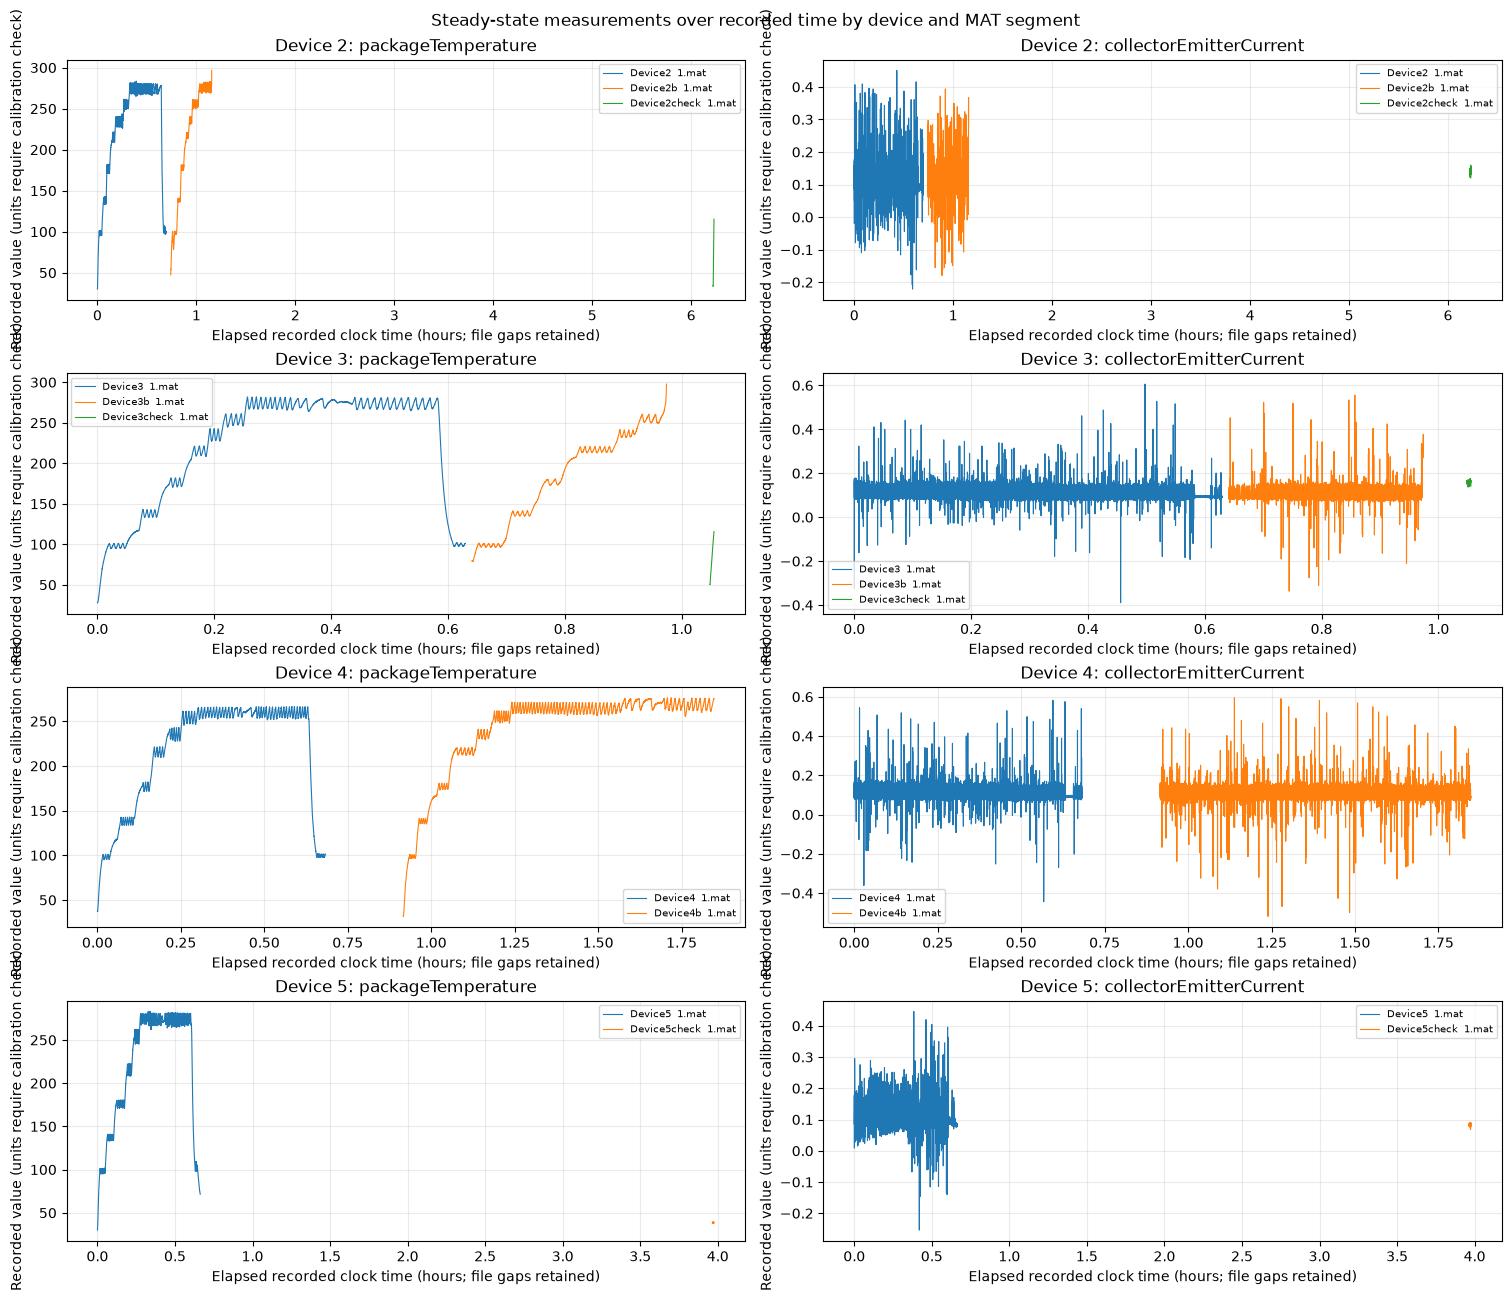

Saved: results/figures/eda_steady_state_time_by_device.png


In [4]:
plot_df = df.loc[np.isfinite(df["timeEpoch"]) & (df["timeEpoch"] > 0)].copy()
if plot_df.empty:
    raise ValueError("No positive finite timeEpoch values are available for time plots.")

first_device_time = plot_df.groupby("device_folder", observed=True)["timeEpoch"].transform("min")
plot_df["elapsed_recorded_hours"] = (plot_df["timeEpoch"] - first_device_time) / 3600

devices = sorted(plot_df["device_folder"].dropna().unique())
fig, axes = plt.subplots(
    nrows=len(devices), ncols=2, figsize=(15, 3.2 * len(devices)),
    squeeze=False, constrained_layout=True
)
channels = ["packageTemperature", "collectorEmitterCurrent"]

for row_index, device in enumerate(devices):
    device_data = plot_df.loc[plot_df["device_folder"] == device]
    for column_index, channel in enumerate(channels):
        ax = axes[row_index, column_index]
        for source_file, file_data in device_data.groupby("source_file", sort=True, observed=True):
            file_data = file_data.sort_values("timeEpoch")
            ax.plot(
                file_data["elapsed_recorded_hours"],
                file_data[channel],
                linewidth=0.8,
                label=Path(source_file).name,
            )
        ax.set_title(f"{device}: {channel}")
        ax.set_xlabel("Elapsed recorded clock time (hours; file gaps retained)")
        ax.set_ylabel("Recorded value (units require calibration check)")
        ax.grid(alpha=0.25)
        ax.legend(fontsize="x-small", loc="best")

fig.suptitle("Steady-state measurements over recorded time by device and MAT segment")
figures_dir = project_root / "results" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
time_figure_path = figures_dir / "eda_steady_state_time_by_device.png"
fig.savefig(time_figure_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {time_figure_path.relative_to(project_root)}")

### Interpreting the time plots

The device-aging log describes staged changes to temperature targets and supply settings, and some files are separate recorded segments. Therefore, a rise/fall pattern may reflect the commanded stress protocol. Check the log at the corresponding time before attributing a change to degradation. Persistent current behavior at comparable operating conditions could motivate a later investigation, but the README's current drift and scaling warnings must first be resolved. A visual trend by itself is not proof of a failure precursor.

## 4. Distributions of the populated measurement channels

Histograms show how often each recorded numeric range appears across the loaded files. Each signal gets its own axis, so differently scaled measurements are not overlaid. The all-missing `ambientTemperature` field is excluded from this figure, rather than plotted as if it had data. These distributions pool multiple devices, stress stages, and file segments.

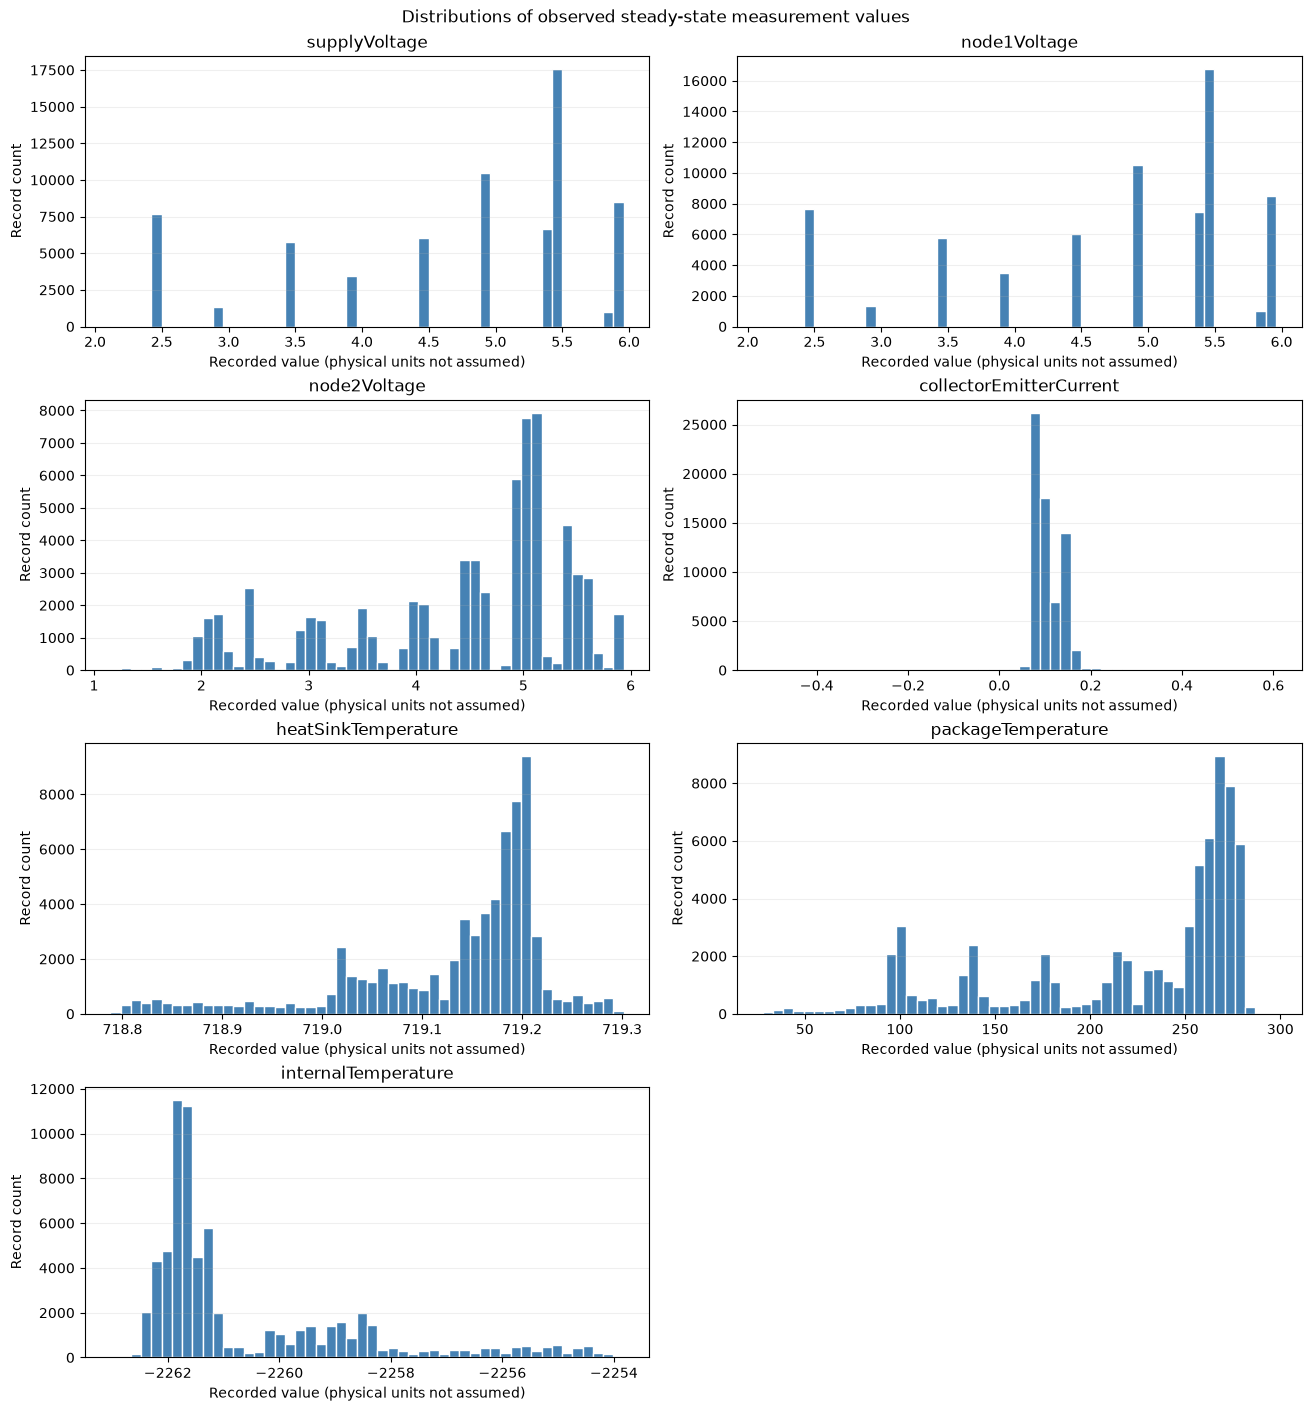

Saved: results/figures/eda_steady_state_signal_distributions.png


In [5]:
populated_signals = [column for column in signal_columns if df[column].notna().any()]
fig, axes = plt.subplots(4, 2, figsize=(13, 14), constrained_layout=True)
axes = axes.ravel()

for ax, column in zip(axes, populated_signals):
    values = df[column].dropna()
    ax.hist(values, bins=50, color="steelblue", edgecolor="white")
    ax.set_title(column)
    ax.set_xlabel("Recorded value (physical units not assumed)")
    ax.set_ylabel("Record count")
    ax.grid(axis="y", alpha=0.2)

for ax in axes[len(populated_signals):]:
    ax.set_visible(False)

fig.suptitle("Distributions of observed steady-state measurement values")
histogram_path = figures_dir / "eda_steady_state_signal_distributions.png"
fig.savefig(histogram_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {histogram_path.relative_to(project_root)}")

### What do the distributions tell us about degradation?

A multimodal histogram can result from several temperature or supply-voltage set points, not several health states. A wide tail can indicate variability, outliers, or measurement problems; it does not say which explanation is correct. Compare these pooled histograms with the time plots and log before treating any mode, spread, or extreme value as a degradation signature. The suspicious numerical scales reinforce the README's calibration warning.

## 5. Compare file-level distributions without hiding segments

These boxplots compare `packageTemperature`, `collectorEmitterCurrent`, and `node2Voltage` across the actual source MAT files. Each box is a distribution summary (median, quartiles, and whiskers); the x-axis labels retain the device and source filename. We choose these three as monitored temperature/current/voltage channels to compare, **not** because they are already validated degradation features. In particular, the notes warn that the steady-state measurements are improperly scaled and the collector current may drift.

**PHM purpose:** check whether measurement distributions differ by device or file segment, which may expose protocol shifts or data-quality differences before any device-to-device comparison.

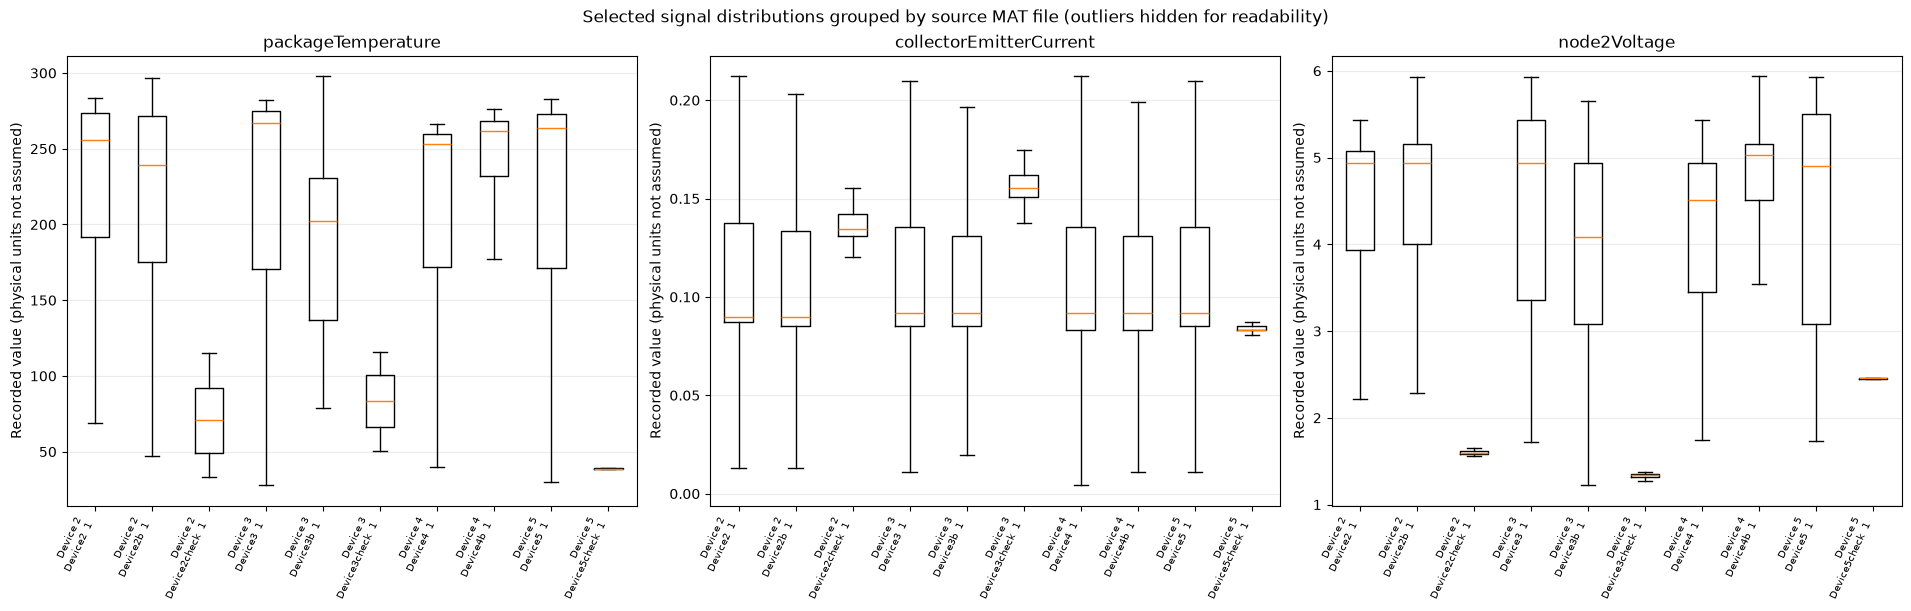

Saved: results/figures/eda_selected_signals_by_source_file.png


In [6]:
file_order = (
    df[["device_folder", "source_file"]]
    .drop_duplicates()
    .sort_values(["device_folder", "source_file"])
)
file_labels = [
    f"{row.device_folder}\n{Path(row.source_file).name.removesuffix('.mat')}"
    for row in file_order.itertuples(index=False)
]
source_files = file_order["source_file"].tolist()
boxplot_signals = ["packageTemperature", "collectorEmitterCurrent", "node2Voltage"]
fig, axes = plt.subplots(1, len(boxplot_signals), figsize=(19, 6), constrained_layout=True)

for ax, column in zip(axes, boxplot_signals):
    grouped_values = [
        df.loc[df["source_file"] == source_file, column].dropna().to_numpy()
        for source_file in source_files
    ]
    ax.boxplot(grouped_values, showfliers=False)
    ax.set_title(column)
    ax.set_ylabel("Recorded value (physical units not assumed)")
    ax.set_xticks(range(1, len(file_labels) + 1), file_labels, rotation=65, ha="right", fontsize=7)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Selected signal distributions grouped by source MAT file (outliers hidden for readability)")
boxplot_path = figures_dir / "eda_selected_signals_by_source_file.png"
fig.savefig(boxplot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {boxplot_path.relative_to(project_root)}")

### What do the file-level boxplots tell us about degradation?

A difference between files could reflect device-to-device variability, a change in experimental set points, a continuation or low-temperature check, or an acquisition/calibration issue. Because each file can cover a different part of the stress protocol, a difference in medians does not establish that one IGBT is more degraded. The whisker summary also hides the time ordering, and this plot hides fliers for readability; use the saved raw values and the time plots for follow-up rather than removing any observation based on this figure.

## 6. Correlation between populated measurement channels

Pearson correlation summarizes pairwise **linear co-variation** among the seven populated scalar signals. Pandas excludes missing pairs when calculating each correlation. Correlation is not causation and this pooled matrix mixes devices and changing test settings, so strong relationships can be driven by the thermal-control protocol rather than aging.

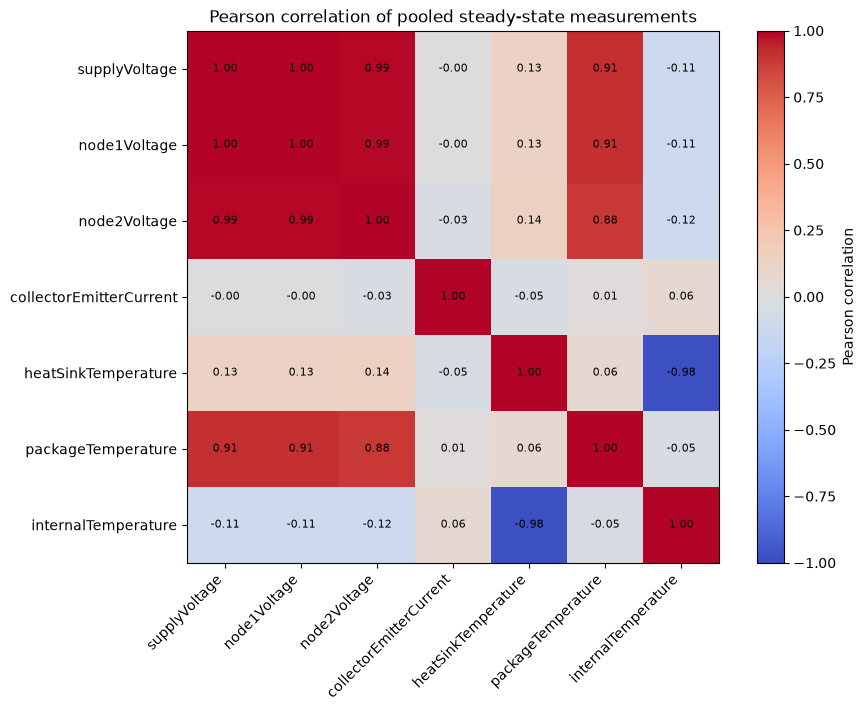

Saved: results/figures/eda_steady_state_correlation.png


In [7]:
correlation = df[populated_signals].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
image = ax.imshow(correlation.to_numpy(), vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(populated_signals)), populated_signals, rotation=45, ha="right")
ax.set_yticks(range(len(populated_signals)), populated_signals)
for row_index in range(len(populated_signals)):
    for column_index in range(len(populated_signals)):
        value = correlation.iloc[row_index, column_index]
        label = "NaN" if pd.isna(value) else f"{value:.2f}"
        ax.text(column_index, row_index, label, ha="center", va="center", fontsize=8)
ax.set_title("Pearson correlation of pooled steady-state measurements")
fig.colorbar(image, ax=ax, label="Pearson correlation")

correlation_path = figures_dir / "eda_steady_state_correlation.png"
fig.savefig(correlation_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {correlation_path.relative_to(project_root)}")

### What does the correlation matrix tell us about degradation?

By itself, it does not establish degradation. It shows which recorded signals vary together across the pooled operating points. A correlation between temperature and an electrical channel may simply reflect the stress-control sequence. Any proposed degradation relationship must be checked within a device, over recorded time, and against the operating-condition log and measurement limitations.

## Phase 3 summary: report observations, not conclusions

Write down:

- Which plots show recognizable stress-temperature cycling or file-to-file gaps?
- Does collector-emitter current look repeatable at comparable apparent operating conditions? How might the documented drift affect your answer?
- Do the histograms or file-level boxplots appear multimodal? Which set-point, device, or file-segment explanations could account for that pattern?
- Which pairs have notable correlations, and what operating-condition confounders could explain them?
- What evidence is still missing before you call any channel a degradation indicator or Health Indicator?

The figures created by this notebook are saved under `results/figures/`. These plots are exploratory diagnostics only; no signal is selected as the HI, no data is cleaned, and no RUL target or model is created. Share your observations and any surprising figures before we decide how to handle the data in the next phase.